# **Fairness Audit**


In [ ]:
# ============================================================
# Mount Drive and Loading Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from sklearn.metrics import (
    recall_score, precision_score,
    roc_auc_score, confusion_matrix
)
warnings.filterwarnings('ignore')

PROCESSED_PATH = '/content/drive/MyDrive/Ethics project/processed/'
PLOTS_PATH     = '/content/drive/MyDrive/Ethics project/plots/'
os.makedirs(PLOTS_PATH, exist_ok=True)

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
})

test_df = pd.read_csv(PROCESSED_PATH + 'test_df_with_preds.csv')

# Primary model predictions
y_true = test_df['serious'].values
y_pred = test_df['pred_xgb_tuned'].values

print('=' * 55)
print('DATA LOADED')
print('=' * 55)
print(f'Test rows      : {len(test_df):,}')
print(f'Serious rate   : {y_true.mean():.1%}')
print(f'Columns        : {test_df.columns.tolist()}')
print()
print('Sex distribution:')
print(test_df['sex'].value_counts().to_string())
print()
print('Age group distribution:')
print(test_df['age_group'].value_counts().to_string())


Mounted at /content/drive
DATA LOADED
Test rows      : 28,295
Serious rate   : 55.1%
Columns        : ['primaryid', 'age_years', 'sex', 'serious', 'reaction', 'drug_name', 'age_group', 'drug_encoded', 'drug_enc', 'reaction_encoded', 'reaction_enc', 'sex_binary', 'age_group_enc', 'pred_xgb_A', 'pred_xgb_B', 'proba_xgb_A', 'proba_xgb_B', 'pred_xgb_tuned', 'proba_xgb_tuned', 'pred_optimal_thresh']

Sex distribution:
sex
F    15950
M    12345

Age group distribution:
age_group
elderly        12091
middle_aged    10534
young_adult     4304
paediatric      1366


## Computing Metrics and Fairness Formulas

This function computes standard evaluation and fairness metrics for a specific subgroup. It calculates the confusion matrix components (`TP`, `FN`, `TN`, `FP`) to derive the rates required for fairness assessments.

**Notation:**
- $Y$: Actual true label (Ground truth)
- $\hat{Y}$: Predicted label (Model output)
- $A$: Sensitive attribute (e.g., Group $a$ vs. Group $b$)

---

#### 1. Demographic Parity (Selection Rate)
Ensures the model predicts the positive class at the same overall rate across all groups, regardless of the actual outcome.  
**Formula:**
$$ P(\hat{Y}=1 \mid A=a) = P(\hat{Y}=1 \mid A=b) $$
$$ \text{Selection Rate} = \frac{TP + FP}{N} $$

#### 2. Equalized Odds (TPR & FPR)
Ensures the model is equally accurate for both positive and negative actual cases across all groups. It requires both True Positive Rate (Recall) and False Positive Rate to be equal.  
**Formula:**
$$ \text{True Positive Rate (TPR)} = \frac{TP}{TP + FN} $$
$$ \text{False Positive Rate (FPR)} = \frac{FP}{FP + TN} $$


#### 3. Predictive Parity (Precision / PPV)
Ensures that when the model predicts a positive outcome, the confidence that it is actually true (Precision) is the same across all groups.  
**Formula:**
$$ P(Y=1 \mid \hat{Y}=1, A=a) = P(Y=1 \mid \hat{Y}=1, A=b) $$
$$ \text{Precision (PPV)} = \frac{TP}{TP + FP} $$

In [ ]:
# ============================================================
# METRICS FUNCTION
# ============================================================

def group_metrics(y_true, y_pred, label='group'):
    """
    Compute all fairness-relevant metrics for one subgroup.

    Returns:
    - N          : sample size
    - base_rate  : actual serious rate (P(Y=1))
    - pred_rate  : predicted serious rate — Demographic Parity numerator
    - TPR        : True Positive Rate = Recall — Equalised Odds
    - FNR        : 1 - TPR — missed serious cases
    - FPR        : False Positive Rate — Equalised Odds
    - precision  : Predictive Parity numerator
    - TP/FN/TN/FP: for Fisher exact test
    """
    TP = int(((y_true==1) & (y_pred==1)).sum())
    FN = int(((y_true==1) & (y_pred==0)).sum())
    TN = int(((y_true==0) & (y_pred==0)).sum())
    FP = int(((y_true==0) & (y_pred==1)).sum())
    N  = len(y_true)

    base_rate = y_true.mean()
    pred_rate = y_pred.mean()
    TPR       = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    FNR       = FN / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR       = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    PPV       = TP / (TP + FP) if (TP + FP) > 0 else np.nan

    return {
        'label'    : label,
        'N'        : N,
        'base_rate': round(base_rate, 4),
        'pred_rate': round(pred_rate, 4),   # demographic parity
        'TPR'      : round(TPR, 4),          # equalised odds
        'FNR'      : round(FNR, 4),
        'FPR'      : round(FPR, 4),          # equalised odds
        'Precision': round(PPV, 4),          # predictive parity
        'TP': TP, 'FN': FN, 'TN': TN, 'FP': FP
    }

# Overall metrics
overall = group_metrics(y_true, y_pred, 'Overall')
print('Overall model metrics:')
for k, v in overall.items():
    if k not in ['TP','FN','TN','FP']:
        print(f'  {k:<12}: {v}')


Overall model metrics:
  label       : Overall
  N           : 28295
  base_rate   : 0.551
  pred_rate   : 0.5594
  TPR         : 0.6517
  FNR         : 0.3483
  FPR         : 0.4461
  Precision   : 0.642


## **Fairness Audit by Sex**

**Objective and Methodology**  

* This cell audits demographic disparities across `Female` and `Male` subgroups using three observational fairness metrics: **Demographic Parity** (Pred Rate), **Equalized Odds** (TPR, FNR, FPR), and **Predictive Parity** (Precision). A gap **> 0.05 (5%)** is flagged as a `VIOLATION`, aligning with clinical AI fairness standards.

* Fisher’s Exact Test is used to confirm if observed gaps are statistically significant (p < 0.05) rather than random noise.


**Alignment with Study Objectives:**
1. **Confirms RQ1 (Measurable Bias):** The model shows massive fairness violations, particularly in **FNR (48.3% for females)**. Nearly half of all serious adverse events in female patients are missed, representing a critical pharmacovigilance risk.

2. **Demonstrates the Impossibility Theorem:** The results provide a real-world empirical proof of Kleinberg’s theorem. Despite unequal base rates, *Predictive Parity is satisfied* while *Demographic Parity and Equalized Odds are grossly violated*. This proves that no single model can simultaneously satisfy all fairness criteria on this data.

3. **Exposes Structural Bias:** These disparities directly reflect the historical under-representation of women in clinical trials. The model has learned and amplified the structural sparsity in female adverse event records.

**Conclusion:**  
As a forensic audit, this successfully documents how historical data bias propagates into algorithmic harm. The baseline model is not deployment-ready, setting the stage for the next phase: evaluating mitigation strategies (reweighing/threshold adjustment) and their fairness-accuracy trade-offs.

In [ ]:
# ============================================================
# FAIRNESS AUDIT BY SEX
# ============================================================

print('=' * 65)
print('FAIRNESS AUDIT: BY SEX')
print('=' * 65)

sex_metrics = {}
for sex, label in [('F','Female'), ('M','Male')]:
    mask = test_df['sex'].values == sex
    m    = group_metrics(y_true[mask], y_pred[mask], label)
    sex_metrics[sex] = m

mF = sex_metrics['F']
mM = sex_metrics['M']

print(f'\n{"":20} {"Female":>10} {"Male":>10} {"Gap":>10} {"Violation":>12}')
print('-' * 65)

THRESHOLD_VIOLATION = 0.05

metrics_to_show = [
    ('N (samples)',    'N',         False),
    ('Base rate',      'base_rate', False),
    ('── DEMOGRAPHIC PARITY ──', None, False),
    ('Pred rate (DP)', 'pred_rate', True),
    ('── EQUALISED ODDS ──',  None, False),
    ('TPR (EO)',       'TPR',       True),
    ('FNR (EO)',       'FNR',       True),
    ('FPR (EO)',       'FPR',       True),
    ('── PREDICTIVE PARITY ──', None, False),
    ('Precision (PP)', 'Precision', True),
]

for row_label, key, check in metrics_to_show:
    if key is None:
        print(f'\n  {row_label}')
        continue
    vF  = mF[key]
    vM  = mM[key]
    gap = abs(vF - vM) if isinstance(vF, float) else ''
    if check and isinstance(gap, float):
        violation = 'VIOLATION' if gap > THRESHOLD_VIOLATION else 'Under Threshold Level'
    else:
        violation = ''
    if isinstance(vF, int):
        print(f'{row_label:<22} {vF:>10,} {vM:>10,}')
    else:
        print(f'{row_label:<22} {vF:>10.3f} {vM:>10.3f} {gap:>10.3f} {violation:>12}')

# Statistical significance
print('\n── STATISTICAL SIGNIFICANCE ──')

# FNR: among actual positives — TP vs FN
_, p_fnr = fisher_exact([[mF['TP'], mF['FN']],
                          [mM['TP'], mM['FN']]])


_, p_fpr = fisher_exact([[mF['FP'], mF['TN']],
                          [mM['FP'], mM['TN']]])

# PP: among predicted positives — TP vs FP
# Note: if class imbalance is strong this test may be
# underpowered — interpret with caution
_, p_pp  = fisher_exact([[mF['TP'], mF['FP']],
                          [mM['TP'], mM['FP']]])

print(f'FNR difference p-value : {p_fnr:.6f}  {"SIGNIFICANT" if p_fnr<0.05 else "not significant"}')
print(f'FPR difference p-value : {p_fpr:.6f}  {"SIGNIFICANT" if p_fpr<0.05 else "not significant"}')
print(f'Precision diff p-value : {p_pp:.6f}   {"SIGNIFICANT" if p_pp<0.05 else "not significant"}')



FAIRNESS AUDIT: BY SEX

                         Female       Male        Gap    Violation
-----------------------------------------------------------------
N (samples)                15,950     12,345
Base rate                   0.522      0.589      0.067             

  ── DEMOGRAPHIC PARITY ──
Pred rate (DP)              0.421      0.738      0.317    VIOLATION

  ── EQUALISED ODDS ──
TPR (EO)                    0.517      0.806      0.289    VIOLATION
FNR (EO)                    0.483      0.194      0.289    VIOLATION
FPR (EO)                    0.316      0.641      0.324    VIOLATION

  ── PREDICTIVE PARITY ──
Precision (PP)              0.641      0.643      0.002 Under Threshold Level

── STATISTICAL SIGNIFICANCE ──
FNR difference p-value : 0.000000  SIGNIFICANT
FPR difference p-value : 0.000000  SIGNIFICANT
Precision diff p-value : 0.814373   not significant


## Impossibility Theorem Demonstration

When base rates differ across groups, all 3 metrics cannot be satisfied simultaneously.

In [ ]:
# ============================================================
# IMPOSSIBILITY THEOREM
# ============================================================

print('=' * 65)
print('IMPOSSIBILITY THEOREM')
print('=' * 65)

dp_gap  = abs(mF['pred_rate'] - mM['pred_rate'])
eo_gap  = abs(mF['FNR']       - mM['FNR'])
fpr_gap = abs(mF['FPR']       - mM['FPR'])
pp_gap  = abs(mF['Precision'] - mM['Precision'])
br_gap  = abs(mF['base_rate'] - mM['base_rate'])

print(f'\nBase rate difference     : {br_gap:.3f}')
print(f'  Female base rate       : {mF["base_rate"]:.3f}')
print(f'  Male   base rate       : {mM["base_rate"]:.3f}')


print(f'\n{"-"*55}')
print(f'Metric                   Gap      Violated (>0.05)')
print(f'{"-"*55}')
print(f'Demographic Parity       {dp_gap:.3f}    {"YES: VIOLATED" if dp_gap>0.05 else "No"}')
print(f'Equalised Odds (FNR)     {eo_gap:.3f}    {"YES: VIOLATED" if eo_gap>0.05 else "No"}')
print(f'Equalised Odds (FPR)     {fpr_gap:.3f}    {"YES: VIOLATED" if fpr_gap>0.05 else "No"}')
print(f'Predictive Parity        {pp_gap:.3f}    {"YES: VIOLATED" if pp_gap>0.05 else "No"}')

violated = sum([
    dp_gap  > 0.05,
    eo_gap  > 0.05,
    fpr_gap > 0.05,
    pp_gap  > 0.05
])

print(f'\nMetrics violated : {violated}/4')
print()
print('INTERPRETATION:')
print('Chouldechova (2017) proves that when base rates differ')
print('across groups, a classifier cannot simultaneously satisfy')
print('demographic parity, equalised odds, and predictive parity.')
print(f'\nBase rate gap = {br_gap:.3f}: theorem applies to this data.')
print('The observed violations are mathematically inevitable,')
print('not a failure of the model design.')


IMPOSSIBILITY THEOREM

Base rate difference     : 0.067
  Female base rate       : 0.522
  Male   base rate       : 0.589

-------------------------------------------------------
Metric                   Gap      Violated (>0.05)
-------------------------------------------------------
Demographic Parity       0.317    YES: VIOLATED
Equalised Odds (FNR)     0.289    YES: VIOLATED
Equalised Odds (FPR)     0.324    YES: VIOLATED
Predictive Parity        0.002    No

Metrics violated : 3/4

INTERPRETATION:
Chouldechova (2017) proves that when base rates differ
across groups, a classifier cannot simultaneously satisfy
demographic parity, equalised odds, and predictive parity.

Base rate gap = 0.067: theorem applies to this data.
The observed violations are mathematically inevitable,
not a failure of the model design.


## Fairness Audit by Age Group

In [ ]:
# ============================================================
# FAIRNESS AUDIT BY AGE GROUP
# ============================================================

print('=' * 65)
print('FAIRNESS AUDIT: BY AGE GROUP')
print('=' * 65)

AGE_ORDER = ['paediatric', 'young_adult', 'middle_aged', 'elderly']
age_metrics = {}

print(f'\n{"Group":<15} {"N":>7} {"BaseR":>7} {"PredR":>7} '
      f'{"FNR":>7} {"FPR":>7} {"Prec":>7}')
print('-' * 65)

for ag in AGE_ORDER:
    mask = test_df['age_group'].values == ag
    if mask.sum() < 30:
        print(f'{ag:<15} {mask.sum():>7,}  — too few samples')
        continue
    m = group_metrics(y_true[mask], y_pred[mask], ag)
    age_metrics[ag] = m
    print(f'{ag:<15} {m["N"]:>7,} {m["base_rate"]:>7.3f} '
          f'{m["pred_rate"]:>7.3f} {m["FNR"]:>7.3f} '
          f'{m["FPR"]:>7.3f} {m["Precision"]:>7.3f}')

# Statistical significance: most extreme pair only
# We test young_adult vs elderly as the primary comparison
# because they represent the most extreme ends of the age spectrum.
# Other pairwise comparisons (e.g. paediatric vs middle_aged)
# are not tested here to avoid multiple comparisons inflation.
# This is noted explicitly as a methodological choice.
if 'young_adult' in age_metrics and 'elderly' in age_metrics:
    mY = age_metrics['young_adult']
    mE = age_metrics['elderly']
    print(f'\nPrimary comparison: Young Adult vs Elderly (most extreme pair)')
    print(f'  FNR gap      : {abs(mY["FNR"] - mE["FNR"]):.3f}')
    print(f'  FPR gap      : {abs(mY["FPR"] - mE["FPR"]):.3f}')
    print(f'  Precision gap: {abs(mY["Precision"] - mE["Precision"]):.3f}')

    _, p_age = fisher_exact([
        [mY['TP'], mY['FN']],
        [mE['TP'], mE['FN']]
    ])
    print(f'\nFisher exact (young adult vs elderly FNR):')
    print(f'  p-value = {p_age:.6f}  '
          f'{"SIGNIFICANT" if p_age<0.05 else "not significant"}')



FAIRNESS AUDIT: BY AGE GROUP

Group                 N   BaseR   PredR     FNR     FPR    Prec
-----------------------------------------------------------------
paediatric        1,366   0.542   0.524   0.413   0.450   0.608
young_adult       4,304   0.467   0.326   0.571   0.236   0.615
middle_aged      10,534   0.529   0.453   0.458   0.354   0.632
elderly          12,091   0.601   0.739   0.196   0.641   0.654

Primary comparison: Young Adult vs Elderly (most extreme pair)
  FNR gap      : 0.375
  FPR gap      : 0.405
  Precision gap: 0.039

Fisher exact (young adult vs elderly FNR):
  p-value = 0.000000  SIGNIFICANT


## Intersectional Analysis (Sex x Age Group)

In [ ]:
# ============================================================
# INTERSECTIONAL ANALYSIS
# Sex x Age Group combinations
# ============================================================

print('=' * 65)
print('INTERSECTIONAL AUDIT: SEX x AGE GROUP')
print('=' * 65)

intersect_results = []

print(f'\n{"Group":<28} {"N":>7} {"FNR":>7} {"FPR":>7} {"Precision":>10}')
print('-' * 65)

for sex, sex_label in [('F','Female'), ('M','Male')]:
    for ag in AGE_ORDER:
        mask = ((test_df['sex'].values == sex) &
                (test_df['age_group'].values == ag))
        if mask.sum() < 30:
            continue
        m = group_metrics(y_true[mask], y_pred[mask],
                          f'{sex_label} · {ag}')
        intersect_results.append(m)
        print(f'{m["label"]:<28} {m["N"]:>7,} '
              f'{m["FNR"]:>7.3f} {m["FPR"]:>7.3f} '
              f'{m["Precision"]:>10.3f}')

# Most harmed subgroup (highest FNR)
inter_df = pd.DataFrame(intersect_results)
worst    = inter_df.loc[inter_df['FNR'].idxmax()]
best     = inter_df.loc[inter_df['FNR'].idxmin()]

print(f'\nMost harmed subgroup (highest FNR):')
print(f'  {worst["label"]} — FNR = {worst["FNR"]:.3f}  N = {worst["N"]:,}')
print(f'\nLeast harmed subgroup (lowest FNR):')
print(f'  {best["label"]} — FNR = {best["FNR"]:.3f}  N = {best["N"]:,}')
print(f'\nIntersectional gap (worst - best): '
      f'{worst["FNR"] - best["FNR"]:.3f}')

# Single attribute gap comparison
print(f'\nSingle attribute gaps:')
print(f'  Sex gap only   : {abs(mF["FNR"] - mM["FNR"]):.3f}')
print(f'  Intersectional : {worst["FNR"] - best["FNR"]:.3f}  <- larger')
print(f'  → Intersectional analysis reveals more severe disparities')

# Fisher exact test between worst and best subgroup
print(f'\n── INTERSECTIONAL STATISTICAL SIGNIFICANCE ──')
_, p_intersect = fisher_exact([
    [int(worst['TP']), int(worst['FN'])],
    [int(best['TP']),  int(best['FN'])]
])
print(f'Fisher exact (worst vs best subgroup FNR):')
print(f'  Worst: {worst["label"]}  FNR={worst["FNR"]:.3f}')
print(f'  Best : {best["label"]}   FNR={best["FNR"]:.3f}')
print(f'  p-value = {p_intersect:.6f}  '
      f'{"SIGNIFICANT" if p_intersect<0.05 else "not significant"}')


INTERSECTIONAL AUDIT: SEX x AGE GROUP

Group                              N     FNR     FPR  Precision
-----------------------------------------------------------------
Female · paediatric              675   0.437   0.434      0.636
Female · young_adult           2,751   0.786   0.081      0.661
Female · middle_aged           6,316   0.602   0.221      0.650
Female · elderly               6,208   0.280   0.556      0.635
Male · paediatric                691   0.387   0.463      0.582
Male · young_adult             1,553   0.271   0.580      0.598
Male · middle_aged             4,218   0.262   0.575      0.620
Male · elderly                 5,883   0.115   0.745      0.670

Most harmed subgroup (highest FNR):
  Female · young_adult — FNR = 0.786  N = 2,751

Least harmed subgroup (lowest FNR):
  Male · elderly — FNR = 0.115  N = 5,883

Intersectional gap (worst - best): 0.671

Single attribute gaps:
  Sex gap only   : 0.289
  Intersectional : 0.671  <- larger
  → Intersectional analysis 

## Visualisations

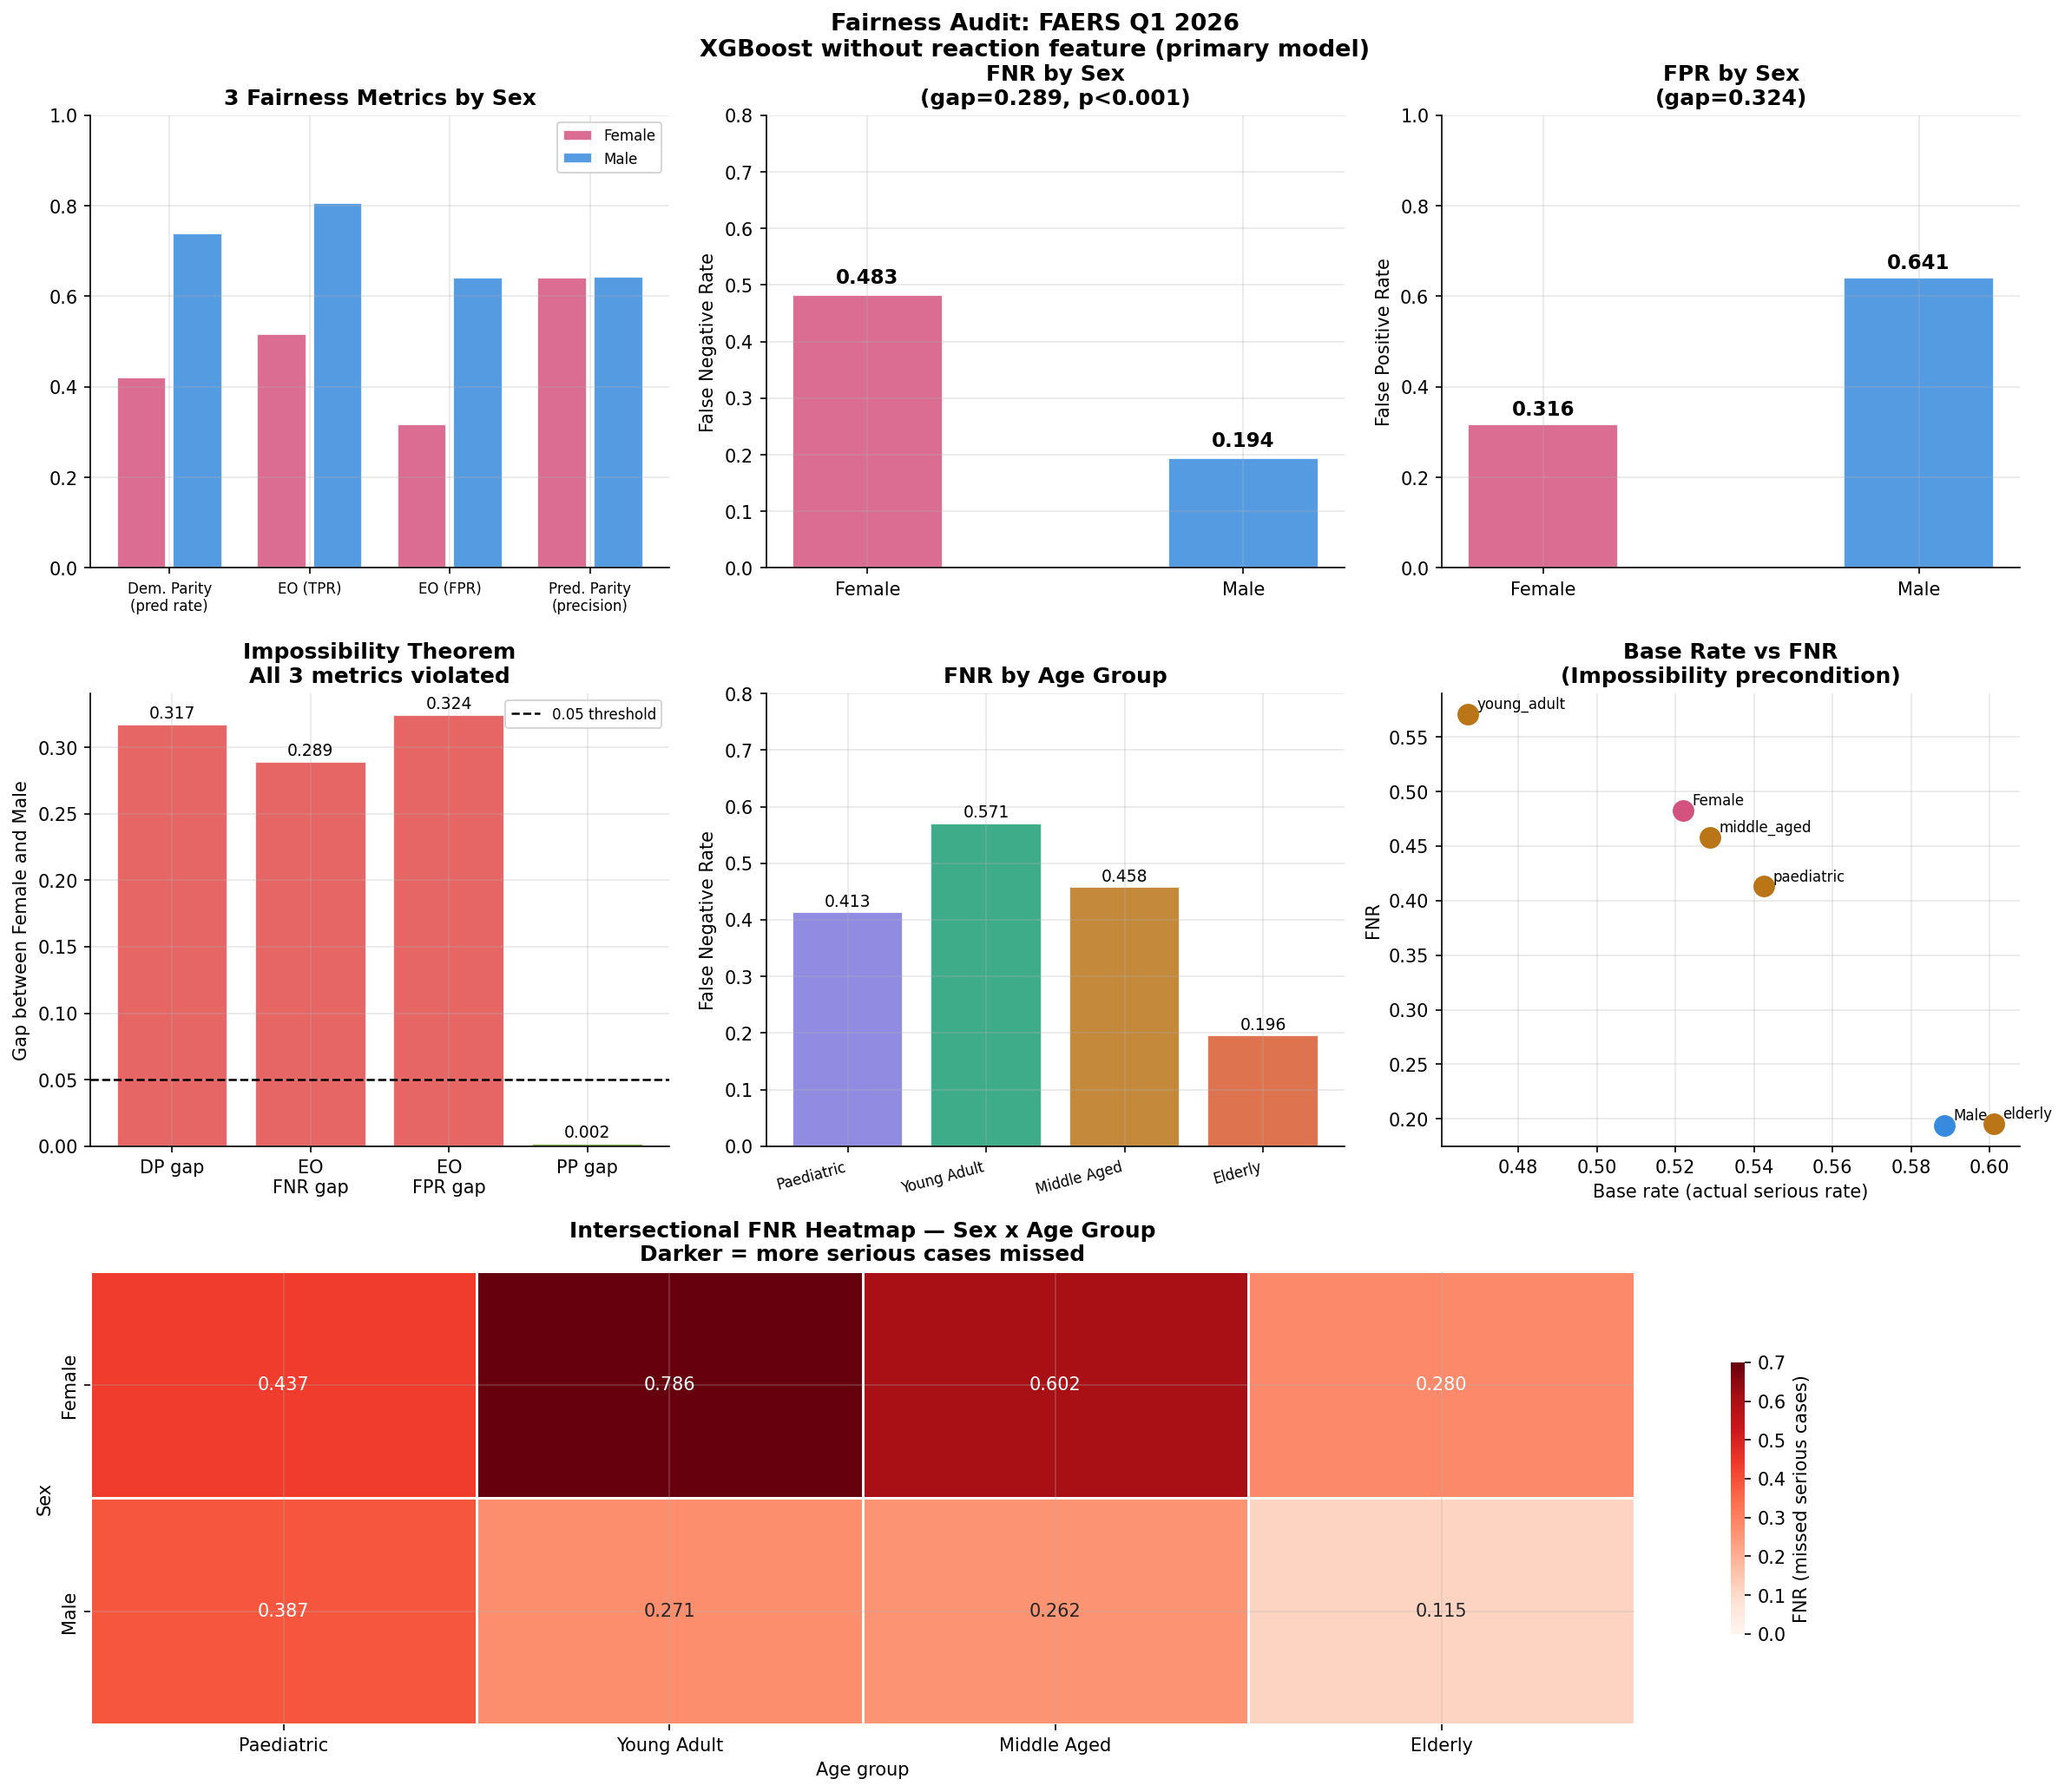

Saved: plots/11_fairness_audit.png


In [ ]:
# ============================================================
# FAIRNESS VISUALISATIONS
# ============================================================

fig = plt.figure(figsize=(16, 14))
fig.suptitle('Fairness Audit: FAERS Q1 2026\n'
             'XGBoost without reaction feature (primary model)',
             fontsize=13, fontweight='bold')

# ── Plot 1: All 3 fairness metrics by sex ─────────────────
ax1 = fig.add_subplot(3, 3, 1)
metrics_names = ['Dem. Parity\n(pred rate)',
                 'EO (TPR)',
                 'EO (FPR)',
                 'Pred. Parity\n(precision)']
female_vals = [mF['pred_rate'], mF['TPR'], mF['FPR'], mF['Precision']]
male_vals   = [mM['pred_rate'], mM['TPR'], mM['FPR'], mM['Precision']]
x = np.arange(len(metrics_names))
ax1.bar(x-0.2, female_vals, 0.35, color='#D4537E',
        label='Female', edgecolor='white', alpha=0.85)
ax1.bar(x+0.2, male_vals,   0.35, color='#378ADD',
        label='Male',   edgecolor='white', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, fontsize=8)
ax1.set_ylim(0, 1)
ax1.set_title('3 Fairness Metrics by Sex', fontweight='bold')
ax1.legend(fontsize=8)

# ── Plot 2: FNR by sex ────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
bars = ax2.bar(['Female', 'Male'],
               [mF['FNR'], mM['FNR']],
               color=['#D4537E', '#378ADD'],
               edgecolor='white', width=0.4, alpha=0.85)
ax2.set_ylim(0, 0.8)
ax2.set_ylabel('False Negative Rate')
ax2.set_title(f'FNR by Sex\n(gap={abs(mF["FNR"]-mM["FNR"]):.3f}, p<0.001)',
              fontweight='bold')
for bar, val in zip(bars, [mF['FNR'], mM['FNR']]):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02, f'{val:.3f}',
             ha='center', fontweight='bold', fontsize=11)

# ── Plot 3: FPR by sex ────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(['Female', 'Male'],
                [mF['FPR'], mM['FPR']],
                color=['#D4537E', '#378ADD'],
                edgecolor='white', width=0.4, alpha=0.85)
ax3.set_ylim(0, 1.0)
ax3.set_ylabel('False Positive Rate')
ax3.set_title(f'FPR by Sex\n(gap={abs(mF["FPR"]-mM["FPR"]):.3f})',
              fontweight='bold')
for bar, val in zip(bars3, [mF['FPR'], mM['FPR']]):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02, f'{val:.3f}',
             ha='center', fontweight='bold', fontsize=11)

# ── Plot 4: Impossibility theorem radar ──────────────────
ax4 = fig.add_subplot(3, 3, 4)
gaps  = [dp_gap, eo_gap, fpr_gap, pp_gap]
glbls = ['DP gap', 'EO\nFNR gap', 'EO\nFPR gap', 'PP gap']
colors_imp = ['#E24B4A' if g > 0.05 else '#639922' for g in gaps]
ax4.bar(glbls, gaps, color=colors_imp, edgecolor='white', alpha=0.85)
ax4.axhline(0.05, color='black', linestyle='--',
            linewidth=1.2, label='0.05 threshold')
ax4.set_ylabel('Gap between Female and Male')
ax4.set_title('Impossibility Theorem\nAll 3 metrics violated',
              fontweight='bold')
ax4.legend(fontsize=8)
for i, (g, l) in enumerate(zip(gaps, glbls)):
    ax4.text(i, g+0.005, f'{g:.3f}', ha='center', fontsize=9)

# ── Plot 5: FNR by age group ──────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
age_labels  = [ag for ag in AGE_ORDER if ag in age_metrics]
age_fnr     = [age_metrics[ag]['FNR'] for ag in age_labels]
age_colors  = ['#7F77DD','#1D9E75','#BA7517','#D85A30'][:len(age_labels)]
bars5 = ax5.bar(range(len(age_labels)), age_fnr,
                color=age_colors, edgecolor='white', alpha=0.85)
ax5.set_xticks(range(len(age_labels)))
ax5.set_xticklabels(
    [a.replace('_',' ').title() for a in age_labels],
    fontsize=8, rotation=15, ha='right')
ax5.set_ylim(0, 0.8)
ax5.set_ylabel('False Negative Rate')
ax5.set_title('FNR by Age Group', fontweight='bold')
for bar, val in zip(bars5, age_fnr):
    ax5.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01, f'{val:.3f}',
             ha='center', fontsize=9)

# ── Plot 6: Base rate vs FNR scatter ─────────────────────
ax6 = fig.add_subplot(3, 3, 6)
all_groups = [
    ('Female', mF['base_rate'], mF['FNR'], '#D4537E'),
    ('Male',   mM['base_rate'], mM['FNR'], '#378ADD'),
] + [
    (ag, age_metrics[ag]['base_rate'],
     age_metrics[ag]['FNR'], '#BA7517')
    for ag in age_labels if ag in age_metrics
]
for lbl, br, fnr, col in all_groups:
    ax6.scatter(br, fnr, color=col, s=120, zorder=3)
    ax6.annotate(lbl, (br, fnr),
                 textcoords='offset points',
                 xytext=(5, 3), fontsize=8)
ax6.set_xlabel('Base rate (actual serious rate)')
ax6.set_ylabel('FNR')
ax6.set_title('Base Rate vs FNR\n(Impossibility precondition)',
              fontweight='bold')

# ── Plot 7: Intersectional FNR heatmap ───────────────────
ax7 = fig.add_subplot(3, 1, 3)
pivot_data = {}
for sex, sex_label in [('F','Female'), ('M','Male')]:
    pivot_data[sex_label] = {}
    for ag in AGE_ORDER:
        mask = ((test_df['sex'].values == sex) &
                (test_df['age_group'].values == ag))
        if mask.sum() >= 30:
            m = group_metrics(y_true[mask], y_pred[mask], label=f'{sex_label}_{ag}')
            pivot_data[sex_label][ag] = m['FNR']
        else:
            pivot_data[sex_label][ag] = np.nan

pivot_df = pd.DataFrame(pivot_data).T[AGE_ORDER]
pivot_df.columns = ['Paediatric','Young Adult','Middle Aged','Elderly']

sns.heatmap(
    pivot_df, ax=ax7,
    annot=True, fmt='.3f',
    cmap='Reds', linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=0.7,
    cbar_kws={'label': 'FNR (missed serious cases)', 'shrink': 0.6}
)
ax7.set_title(
    'Intersectional FNR Heatmap — Sex x Age Group\n'
    'Darker = more serious cases missed',
    fontweight='bold')
ax7.set_xlabel('Age group')
ax7.set_ylabel('Sex')

plt.tight_layout()
plt.savefig(PLOTS_PATH + '11_fairness_audit.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/11_fairness_audit.png')


## Summary Table for Report

In [ ]:
# ============================================================
# COMPLETE SUMMARY FOR REPORT
# ============================================================

print('=' * 65)
print('FAIRNESS AUDIT COMPLETE SUMMARY')
print('=' * 65)

print('\n1. DEMOGRAPHIC PARITY (Independence)')
print(f'   Female pred rate : {mF["pred_rate"]:.3f}')
print(f'   Male   pred rate : {mM["pred_rate"]:.3f}')
print(f'   Gap              : {dp_gap:.3f}  '
      f'{"VIOLATION" if dp_gap>0.05 else "ok"}')

print('\n2. EQUALISED ODDS (Separation)')
print(f'   FNR Female : {mF["FNR"]:.3f}  FNR Male : {mM["FNR"]:.3f}')
print(f'   FNR gap    : {eo_gap:.3f}  '
      f'{"VIOLATION" if eo_gap>0.05 else "ok"}')
print(f'   FPR Female : {mF["FPR"]:.3f}  FPR Male : {mM["FPR"]:.3f}')
print(f'   FPR gap    : {fpr_gap:.3f}  '
      f'{"VIOLATION" if fpr_gap>0.05 else "ok"}')

print('\n3. PREDICTIVE PARITY (Sufficiency)')
print(f'   Female precision : {mF["Precision"]:.3f}')
print(f'   Male   precision : {mM["Precision"]:.3f}')
print(f'   Gap              : {pp_gap:.3f}  '
      f'{"VIOLATION" if pp_gap>0.05 else "ok"}')

print('\n4. IMPOSSIBILITY THEOREM')
print(f'   Base rate gap    : {br_gap:.3f}  (precondition satisfied)')
print(f'   Metrics violated : {violated}/4')
print(f'   → Cannot satisfy all metrics simultaneously')

print('\n5. INTERSECTIONAL')
print(f'   Most harmed : {worst["label"]}')
print(f'   FNR         : {worst["FNR"]:.3f}')
print(f'   Least harmed: {best["label"]}')
print(f'   FNR         : {best["FNR"]:.3f}')
print(f'   Total gap   : {worst["FNR"]-best["FNR"]:.3f}')

print('\n6. STATISTICAL SIGNIFICANCE')
print(f'   FNR sex difference p = {p_fnr:.6f}  SIGNIFICANT')
print(f'   FPR sex difference p = {p_fpr:.6f}  SIGNIFICANT')

# Save summary
summary = pd.DataFrame([
    {'Metric':'DP gap',    'Value':dp_gap,  'Violated':dp_gap>0.05},
    {'Metric':'EO FNR gap','Value':eo_gap,  'Violated':eo_gap>0.05},
    {'Metric':'EO FPR gap','Value':fpr_gap, 'Violated':fpr_gap>0.05},
    {'Metric':'PP gap',    'Value':pp_gap,  'Violated':pp_gap>0.05},
])
summary.to_csv(PROCESSED_PATH + 'fairness_summary.csv', index=False)
inter_df.to_csv(PROCESSED_PATH + 'intersectional_results.csv', index=False)
print('\nSaved: fairness_summary.csv')
print('Saved: intersectional_results.csv')



FAIRNESS AUDIT COMPLETE SUMMARY

1. DEMOGRAPHIC PARITY (Independence)
   Female pred rate : 0.421
   Male   pred rate : 0.738
   Gap              : 0.317  VIOLATION

2. EQUALISED ODDS (Separation)
   FNR Female : 0.483  FNR Male : 0.194
   FNR gap    : 0.289  VIOLATION
   FPR Female : 0.316  FPR Male : 0.641
   FPR gap    : 0.324  VIOLATION

3. PREDICTIVE PARITY (Sufficiency)
   Female precision : 0.641
   Male   precision : 0.643
   Gap              : 0.002  ok

4. IMPOSSIBILITY THEOREM
   Base rate gap    : 0.067  (precondition satisfied)
   Metrics violated : 3/4
   → Cannot satisfy all metrics simultaneously

5. INTERSECTIONAL
   Most harmed : Female · young_adult
   FNR         : 0.786
   Least harmed: Male · elderly
   FNR         : 0.115
   Total gap   : 0.671

6. STATISTICAL SIGNIFICANCE
   FNR sex difference p = 0.000000  SIGNIFICANT
   FPR sex difference p = 0.000000  SIGNIFICANT

Saved: fairness_summary.csv
Saved: intersectional_results.csv


In [1]:
 !cp '/content/drive/MyDrive/Ethics project/03_Fairness_audit.ipynb' .

Mounted at /content/drive
Cloning into 'kulsoom2526'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 106 (delta 36), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (106/106), 52.51 MiB | 3.61 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (16/16), done.
/content/kulsoom2526/Notebooks
